# \# Smart Cart Clustering System

## \# E-Commerce Customer Segmentaion System

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df = pd.read_csv("smartcart_customers.csv")

## -> data preprocessing

## 1. Handle the missing Values

In [91]:
df["Income"] = df["Income"].fillna(df["Income"].median())

## 2. Feature Engineering

In [92]:
# age
df["Age"] = 2026-df["Year_Birth"]

In [93]:
# customer tenure days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days


In [94]:
# total spending -> wines + fruits + meat_products + fish + sweet + gold

df["Total_Spending"] = (
    df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] +
    df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]
)


In [95]:
# total children -> kids + teen ager

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [96]:
# Education 

df["Education"].value_counts()

# undergraduate, graduate, postgraduate
df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate", "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Postgraduate", "PhD" : "Postgraduate"
})


df["Education"].value_counts()


Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [97]:
# Marital Status
df["Marital_Status"].value_counts()

df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner", "Together" : "Partner",
    "Single" : "Alone","Divorced" : "Alone", "Widow" : "Alone",
    "Absurd" : "Alone", "YOLO" :"Alone"
})

## Drop Column

In [98]:
columns_to_drop = ["ID", "Marital_Status", "MntWines", "MntFruits", "MntMeatProducts",
                   "MntFishProducts", "MntSweetProducts", "MntGoldProds", "Kidhome", "Teenhome",
                   "Year_Birth", "Dt_Customer"
                  ]
df_cleaned = df.drop(columns = columns_to_drop)

# \# Handle Outliers

In [99]:
cols = ["Income", "Recency", "Response", "Age", "Total_Spending", "Total_Children"]

# relative plots of some features - pair plot
# sns.pairplot(df_cleaned[cols])


In [100]:
# revomve the outlier

print("Data size with outliers : ", len(df_cleaned))

df_cleaned = df_cleaned[df_cleaned["Age"] < 90]
df_cleaned = df_cleaned[df_cleaned["Income"] < 600_000]

print("Data size withoud outliers : ", len(df_cleaned))

Data size with outliers :  2240
Data size withoud outliers :  2236


# \# Heatmap of features

In [101]:
corr = df_cleaned.corr(numeric_only=True)

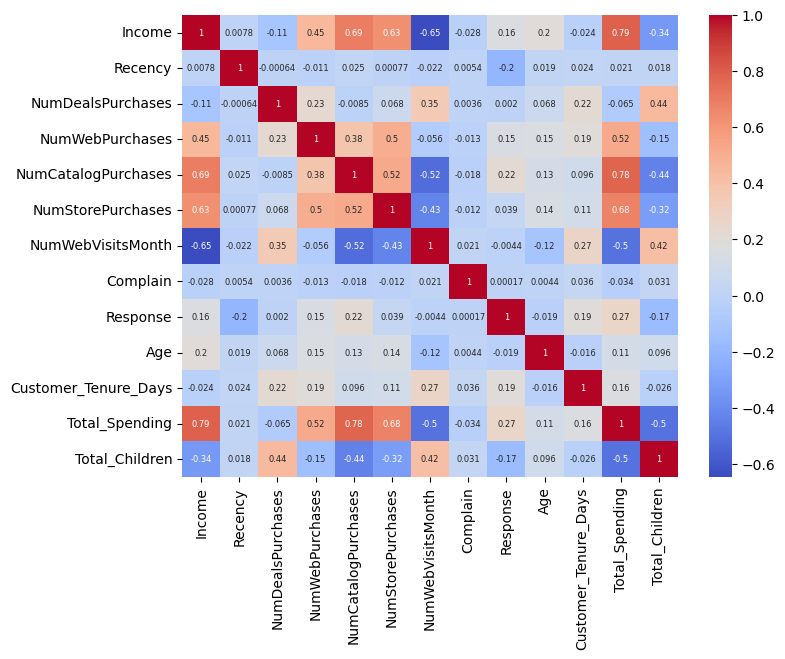

In [102]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws = {"size":6},
    cmap = "coolwarm"
)
plt.show()

In [103]:
df_cleaned.shape

(2236, 15)

In [104]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# \# Feature Encoding and Scale

In [105]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [106]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [107]:
enc_df = pd.DataFrame(
    enc_cols.toarray(),
    columns=ohe.get_feature_names_out(cat_cols),
    index=df_cleaned.index
)

In [108]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

In [109]:
X = df_encoded

In [110]:
# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# visualize

In [111]:
X_scaled.shape # 18 dimenstion ko visualized krna is not possible so we're using pca

(2236, 18)

## PCA for visualization

In [128]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)

X_pca = pca.fit_transform(X_scaled)

<Axes: >

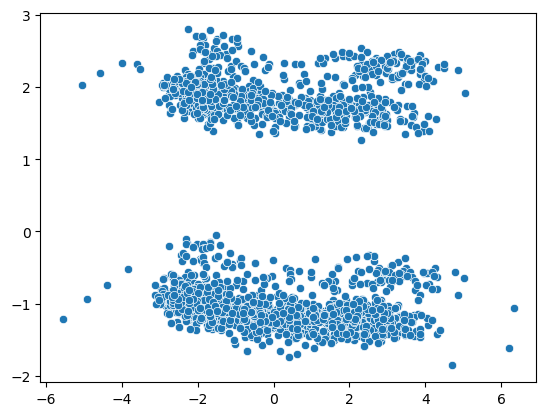

In [129]:
# plot 2d
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1])

In [130]:
pca.explained_variance_ratio_ # 34% variance captured

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D projection')

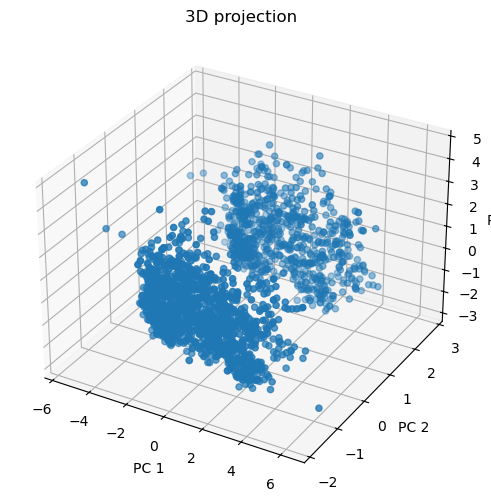

In [131]:
# for higher dimensions 
# 3d
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
ax.set_title("3D projection")


# Analysize K value

@ 1. Elbow Method

Text(0, 0.5, 'WCSS')

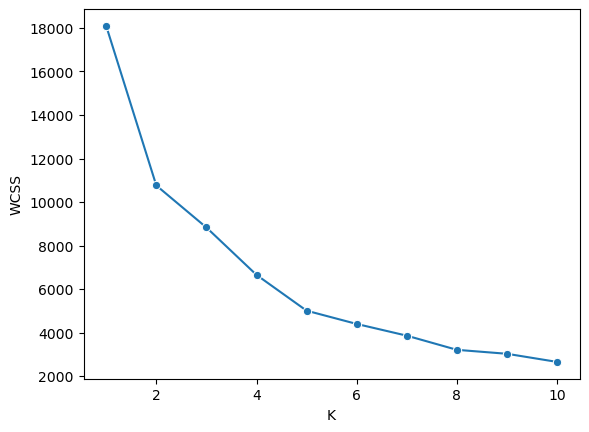

In [132]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

# plot k vs wcss

sns.lineplot(x=range(1,11), y=wcss,marker ='o')
plt.xlabel("K")
plt.ylabel("WCSS")

In [133]:
knee = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow
print("best k = ", optimal_k)

best k =  4


Text(0, 0.5, 'Silhouette Score')

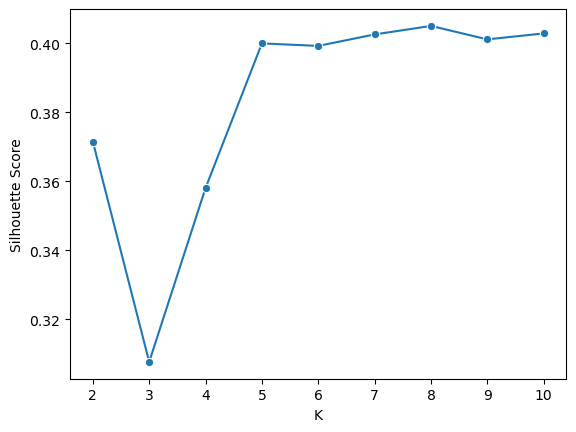

In [134]:
# using silhouette score
from sklearn.metrics import silhouette_score

ss = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score =  silhouette_score(X_pca, labels)
    ss.append(score)
    
# plot
sns.lineplot(x=range(2,11), y=ss, marker="o")
plt.xlabel("K")
plt.ylabel("Silhouette Score")

# clustering

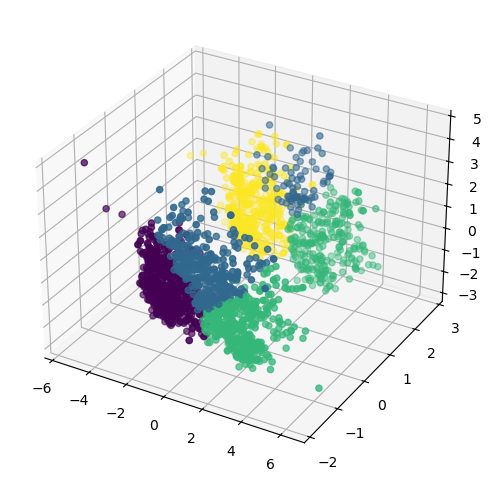

In [135]:
#KMeans
kmeans = KMeans(n_clusters=4, random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)

# plot

fig = plt.figure(figsize=(8,6))
axes = fig.add_subplot(111, projection="3d")
axes.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = labels_kmeans)


In [137]:
# agllomerative clusterfing

from sklearn.cluster import AgglomerativeClustering

In [141]:
agg_cls = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_cls.fit_predict(X_pca)

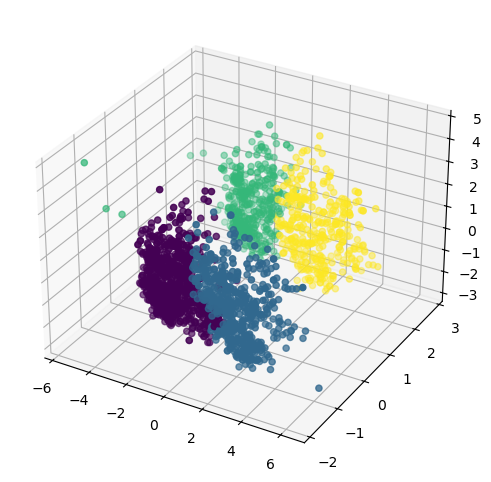

In [142]:
# plot
fig = plt.figure(figsize=(8,6))
axes = fig.add_subplot(111, projection="3d")
axes.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = labels_agg)


# Characterization of clusters

In [159]:
X["cluster"] = labels_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

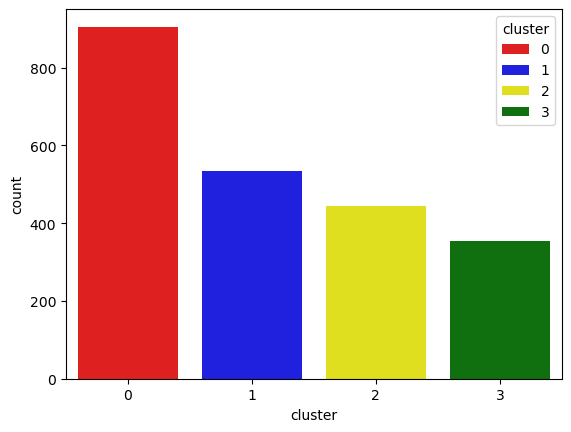

In [160]:
# No. of customers in each cluster

pal = ["red", "blue", "yellow", "green"]
sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

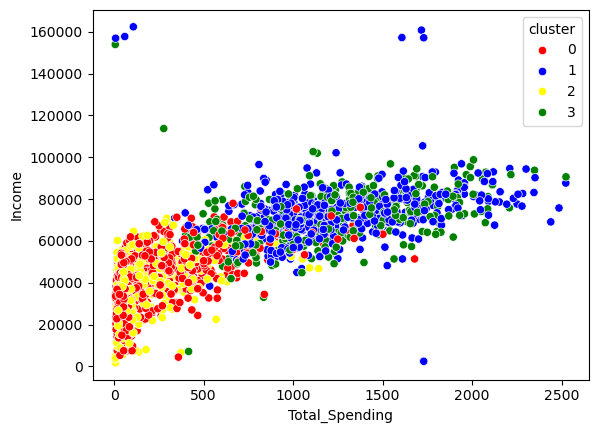

In [161]:
# income and spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [164]:
# cluster summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         